# Project 1

## Domain and parameters

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
from scipy.sparse import spdiags
import matplotlib.patheffects as pe

In [2]:
# matplotlib.rcParams.update({
#     "text.usetex": False,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],  # default pdflatex font
# })

In [3]:
a = 0.005
Nx = 50
Ny = 50
L = 1
ix = np.linspace(1, Nx, Nx)  
iy = np.linspace(1, Ny, Ny)

x = ix/(Nx+1)
y = iy/(Ny+1)

# meshgrid
[Y, X] = np.meshgrid(y, x)  # FIX: removed indexing='xy' to match MATLAB default

k = 0.02 * np.exp(-((X-0.7)**2/0.09 + (Y-0.6)**2/0.25))

dx = x[1] - x[0]
dy = y[1] - y[0]
dt = 0.01
index = np.arange(0, Nx * Ny).reshape((Nx, Ny), order='F')
k_flat = k.reshape(-1, order='F')
# boundary conditions
BCL_D = 0.5 - 0.5 * np.cos(2 * np.pi * y)
BCR_N = np.zeros(len(y))
BCB_N = -0.3 * np.ones(len(x))
BCT_D = 0.5 + 0.5 * np.sin(4*np.pi * x - 0.5*np.pi)

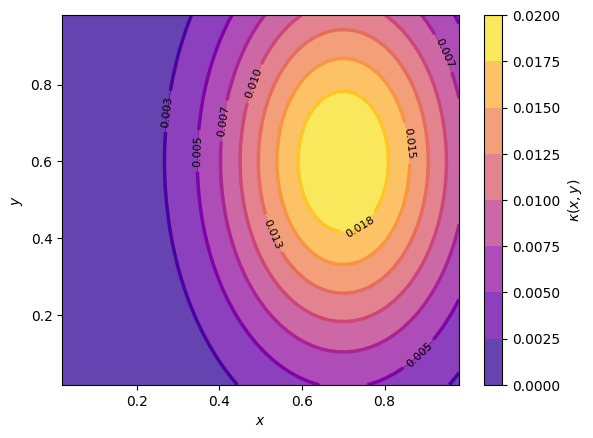

In [4]:
plt.contourf(X, Y, k, levels=8, cmap='plasma', alpha = 0.75)
plt.colorbar(label=r'$\kappa(x,y)$')

c = plt.contour(X, Y, k, levels=8, cmap='plasma', linewidths=2.5)
clabels = plt.clabel(c, inline=True, fontsize=8, colors='black', fmt='%.3f')

# plt.title(r'contour of source term $\kappa(x,y)$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.savefig('contour_kappa.png', dpi=300)

## Laplace Matrices

In [5]:
def Laplace_u(u, Nx, Ny, index, dx, dy):
    value = np.zeros_like(u)
    # internal nodes
    for j in range(1, Ny-1):
        for i in range(1, Nx-1):
            idx = index[i, j]
            value[idx] = (u[index[i+1, j]] - 2*u[idx] + u[index[i-1, j]]) / dx**2 + \
                         (u[index[i, j+1]] - 2*u[idx] + u[index[i, j-1]]) / dy**2
    # west boundary (dirichlet)
    i = 0
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = (-2*u[idx] + u[index[i+1, j]]) / dx**2 + \
                      + (u[index[i, j+1]] - 2*u[idx] + u[index[i, j-1]]) / dy**2
    # east boundary (neumann)
    i = Nx-1
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = (u[index[i-1, j]] - u[idx]) / dx**2 + \
                      + (u[index[i, j+1]] - 2*u[idx] + u[index[i, j-1]]) / dy**2
    # north boundary (dirichlet)
    j = Ny-1  
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = (u[index[i+1, j]] - 2*u[idx] + u[index[i-1, j]]) / dx**2 + \
                      + (-2*u[idx] + u[index[i, j-1]]) / dy**2
    # south boundary (neumann)
    j = 0
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = (u[index[i+1, j]] - 2*u[idx] + u[index[i-1, j]]) / dx**2 + \
                      + (u[index[i, j+1]] - u[idx]) / dy**2
    # corners
    # southwest corner (west dirichlet + south neumann)
    i, j = 0, 0
    idx = index[i, j]
    value[idx] = (-2*u[idx] + u[index[i+1, j]]) / dx**2 + \
                  + (u[index[i, j+1]] - u[idx]) / dy**2
    # southeast corner (east neumann + south neumann)
    i, j = Nx-1, 0
    idx = index[i, j]
    value[idx] = (u[index[i-1, j]] - u[idx]) / dx**2 + \
                  + (u[index[i, j+1]] - u[idx]) / dy**2
    # northwest corner (west dirichlet + north dirichlet)
    i, j = 0, Ny-1
    idx = index[i, j]
    value[idx] = (-2*u[idx] + u[index[i+1, j]]) / dx**2 + \
                  + (-2*u[idx] + u[index[i, j-1]]) / dy**2
    # northeast corner (east neumann + north dirichlet)
    i, j = Nx-1, Ny-1
    idx = index[i, j]
    value[idx] = (u[index[i-1, j]] - u[idx]) / dx**2 + \
                  + (-2*u[idx] + u[index[i, j-1]]) / dy**2
    return value

In [6]:
def Laplace_BC(Nx, Ny, index, dx, dy, BCL_D, BCR_N, BCB_N, BCT_D):
    value = np.zeros(Nx*Ny)

    # west boundary (dirichlet)
    i = 0
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = BCL_D[j] / dx**2

    # east boundary (neumann)
    i = Nx-1
    for j in range(1, Ny-1):
        idx = index[i, j]
        value[idx] = BCR_N[j] / dx  

    # north boundary (dirichlet)
    j = Ny-1
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = BCT_D[i] / dy**2

    # south boundary (neumann)
    j = 0
    for i in range(1, Nx-1):
        idx = index[i, j]
        value[idx] = -BCB_N[i] / dy  

    # corners
    # southwest corner (west dirichlet + south neumann)
    i, j = 0, 0
    idx = index[i, j]
    value[idx] = BCL_D[j] / dx**2 - BCB_N[i] / dy

    # southeast corner (east neumann + south neumann)
    i, j = Nx-1, 0
    idx = index[i, j]
    value[idx] = BCR_N[j] / dx - BCB_N[i] / dy 

    # northwest corner (west dirichlet + north dirichlet)
    i, j = 0, Ny-1
    idx = index[i, j]
    value[idx] = BCL_D[j] / dx**2 + BCT_D[i] / dy**2

    # northeast corner (east neumann + north dirichlet)
    i, j = Nx-1, Ny-1
    idx = index[i, j]
    value[idx] = BCR_N[j] / dx + BCT_D[i] / dy**2 

    return value

## Set Up Problem

In [7]:
LHS = lambda u: -a * Laplace_u(u, Nx, Ny, index, dx, dy)

LBC = Laplace_BC(Nx, Ny, index, dx, dy, BCL_D, BCR_N, BCB_N, BCT_D)

RHS = k_flat + a*LBC

## Conjugate Gradient Solver

In [8]:
def cg_solver(LHS, RHS, x0, tol, maxit):
    u = x0.copy()
    r = RHS - LHS(u)
    p = r.copy()
    res0 = np.linalg.norm(r)
    resvec = np.zeros(maxit)

    for iter in range(1, maxit + 1):
        LHS_p = LHS(p)
        alpha = (r @ r) / (p @ LHS_p)

        u = u + alpha * p
        r_new = r - alpha * LHS_p

        resvec[iter - 1] = np.linalg.norm(r_new) / res0

        if resvec[iter - 1] < tol:
            resvec = resvec[:iter]
            return u, iter, resvec

        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new

    resvec = resvec[:iter]
    return u, iter, resvec

## Steady State Solution 

In [9]:
x0 = np.zeros(Nx * Ny)
tol = 1e-8
maxit = 5000

In [10]:
[U, iter, resvec] = cg_solver(LHS, RHS, x0, tol, maxit)
print(f'CG converged in {iter} iterations with final residual {resvec[-1]:.2e}')

CG converged in 182 iterations with final residual 8.04e-09


In [11]:
U_ss = U.reshape(Nx, Ny).T

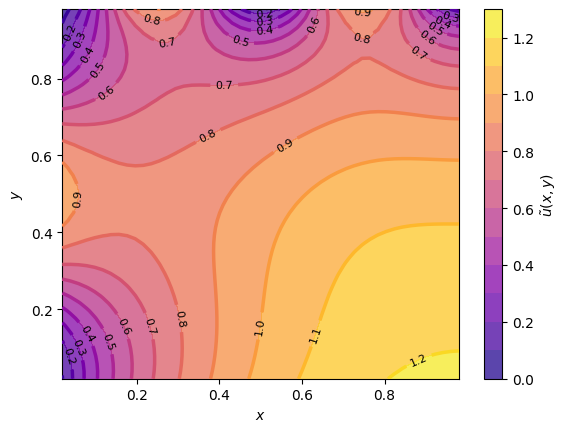

In [12]:
plt.figure()
colormap = 'plasma'
# Smooth fill with many levels
cf = plt.contourf(X, Y, U_ss, levels=12, cmap=colormap, alpha=0.75, zorder=1)
plt.colorbar(cf, label=r'$\tilde{u}(x,y)$')
# Contour lines colored by the colormap, drawn on top
c = plt.contour(X, Y, U_ss, levels=12, cmap=colormap, linewidths=2.5, zorder=5)
# Labels drawn on top of everything
plt.clabel(c, inline=True, fontsize=8, fmt='%0.1f', zorder=10, colors='black')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

# Save figure
plt.savefig('solution_contour.png', dpi=300)
plt.show()

## Heat Equation

In [33]:
# Crank-Nicolson for transient heat equation
dt = 0.1
alpha = a
A_CN = lambda u: u - (alpha * dt / 2) * Laplace_u(u, Nx, Ny, index, dx, dy)
uT = k_flat.copy()
L_BC = Laplace_BC(Nx, Ny, index, dx, dy, BCL_D, BCR_N, BCB_N, BCT_D)
U_ss_vector = U_ss.reshape(-1, order='F')

maxit_Heat = 5000
tol = 1e-4
maxit_CG = 5000
time_stop = None

# Storage: list of (time, solution_2D) tuples
history = [(0.0, uT.reshape(Nx, Ny, order='F'))]

for it in range(1, maxit_Heat + 1):

    L_int = Laplace_u(uT, Nx, Ny, index, dx, dy)
    RHS = alpha * dt / 2 * (L_int + 2 * L_BC) + dt * k_flat + uT
    uT, it_cg, res_cg = cg_solver(A_CN, RHS, uT, tol, maxit_CG)

    # Save current timestep
    history.append((it * dt, uT.reshape(Nx, Ny, order='F')))

    print(f'iterations: {it}', end='\r')

    if np.linalg.norm(uT - U_ss_vector, 2) / np.linalg.norm(U_ss_vector, 2) < 1e-4:
        time_stop = it * dt
        print(f'Converged at t = {time_stop:.4f} ({it} timesteps)')
        break

if time_stop is None:
    print('Did not converge within maximum iterations')

Converged at t = 362.4000 (3624 timesteps)


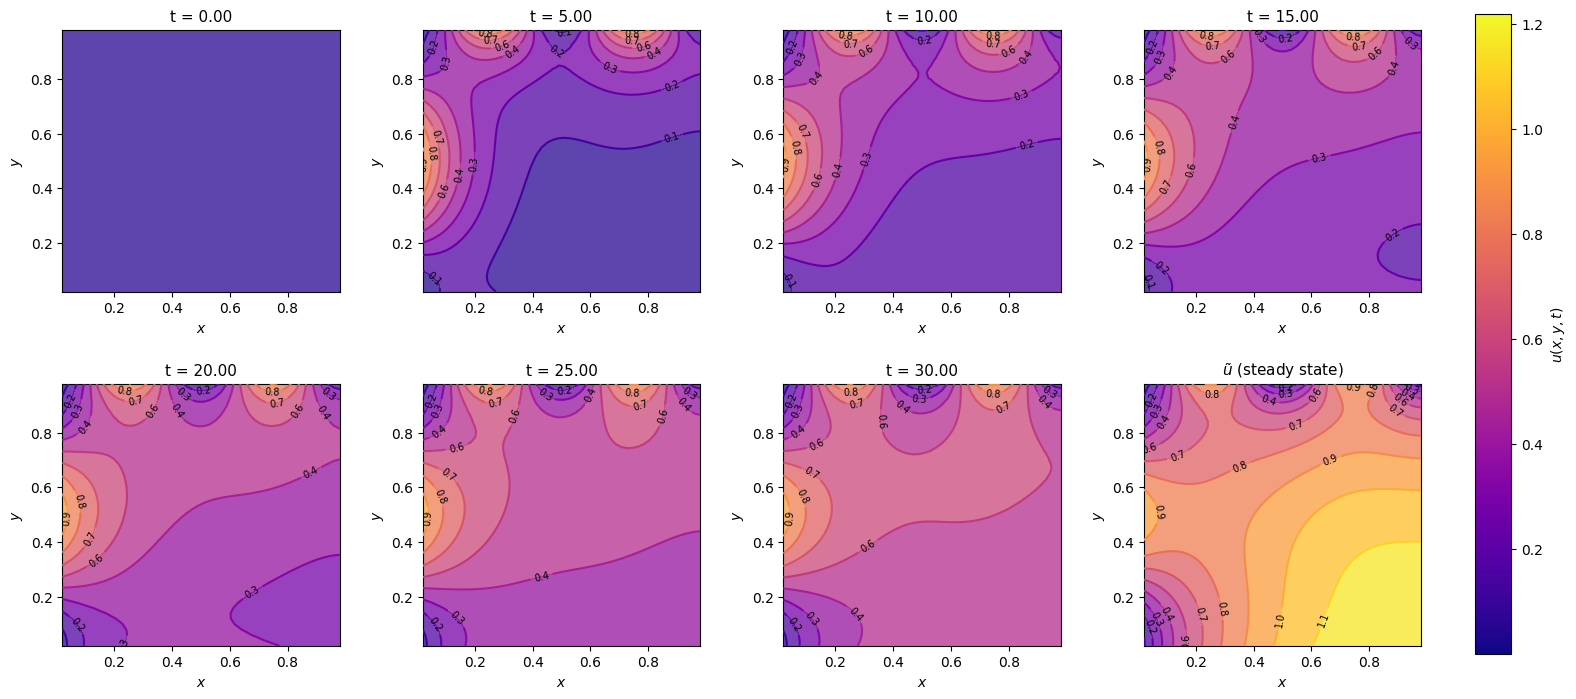

In [34]:
steps_to_plot = [0, 50, 100, 150, 200, 250, 300, -1]  # -1 = final (steady state)
labels = [f't = {history[s][0]:.2f}' for s in steps_to_plot[:-1]] + [r'$\tilde{u}$ (steady state)']

# Compute global min/max for consistent colorbar
vmin = min(history[s][1].min() for s in steps_to_plot)
vmax = max(history[s][1].max() for s in steps_to_plot)

colormap = 'plasma'
levels = np.linspace(vmin, vmax, 12)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, step, label in zip(axes, steps_to_plot, labels):
    t_val, U_plot = history[step]
    cf = ax.contourf(X, Y, U_plot, levels=levels, cmap=colormap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)
    c  = ax.contour( X, Y, U_plot, levels=levels, cmap=colormap, linewidths=1.5, vmin=vmin, vmax=vmax, zorder=5)
    ax.clabel(c, inline=True, fontsize=7, fmt='%0.1f', zorder=10, colors='black')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')

# Single shared colorbar on the right
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.3)
cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, cax=cbar_ax, label=r'$u(x,y,t)$')

plt.savefig('solution_timesteps.png', dpi=300, bbox_inches='tight')
plt.show()